# Notebook Description

This notebook contains the code used to generate the example shown in **Figure 5** of the paper. Specifically, we produce  
* a raster $\mathcal{R}$ with a non-trivial 1-dimensional feature, and  
* a raster $\mathcal{R}'$ that lacks a 1-dimensional feature but is similar in connectivity to $\mathcal{R}$.

The goal is to show that information in neural ensembles may be encoded in higher-dimensional topological features. Please refer to Section **4.2 Results with Synthetic Data**, *TDA Detects Higher-Order Structure Beyond Connectivity*, for a more thorough explanation.


In [1]:
# Load utils
from utils import *

## Create a Raster with Cascading Pattern but no noise

We use the following function to generate rasters with a cascading pattern but without noise. You can adjust the hyperparameters, such as `freq`, to produce similar examples. Running the function with the default settings will reproduce the example shown in the paper.


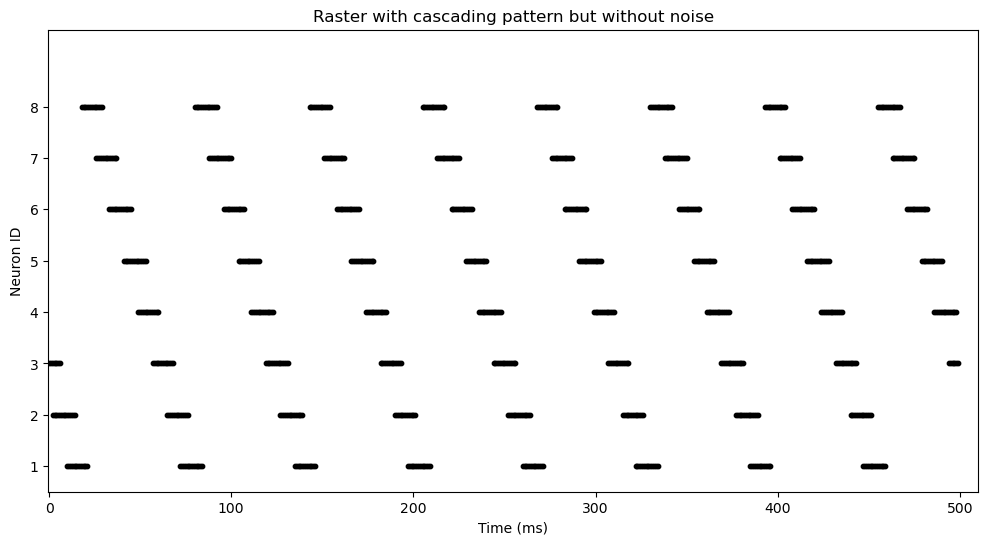

In [2]:
def make_circular_raster(n_trains=20, T=200, freq=2, duty_cycle=0.5, seed=None):
    """
    Construct a raster whose spike trains lie in a loop (approximately) with respect to Victor-Purpura distance

    Parameters
    ----------
    n_trains : int
        Number of spike trains (rows).
    T : int
        Maximum time (columns).
    freq : float
        Temporal frequency of the oscillation over [0, T).
    duty_cycle : float in (0,1)
        Fraction of bins that are 'active' (spikes) per train.
    seed : int or None
        Random seed for reproducibility.
        
    Returns
    -------
    raster : (n_trains, T) int array
    """
    if seed is not None:
        np.random.seed(seed)

    time = np.arange(T)
    raster = np.zeros((n_trains, T), dtype=int)

    thresh = np.cos(np.pi * duty_cycle)

    for i in range(n_trains):
        phase = 2 * np.pi * i / n_trains  # equally spaced phases around a circle
        signal = np.sin(2 * np.pi * freq * time / T + phase)

        active = signal > thresh
        raster[i, active] = 1

    return raster

# create a raster without noise
raster = make_circular_raster(n_trains =8, T=500,
                               freq=8, 
                               duty_cycle=0.2
                              ,seed=0) 

plot_raster(raster,title ='Raster with cascading pattern but without noise') # Plot raster
plt.show()



# Figure 5A: Raster $\mathcal{R}$

Use the code below to reproduce Figure 5A from the paper.  
Note that the final version of the figure was further refined in Adobe Illustrator.

We add noise to the raster above by  
* shifting spikes,
* adding spikes, and
* removing existing spikes

each with a given probability.

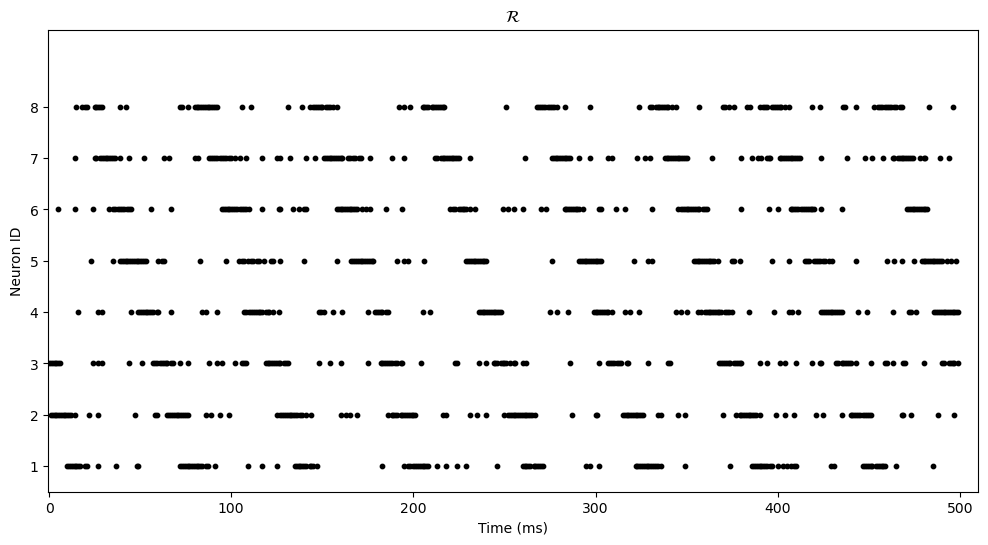

In [3]:
# Adding noise to the original raster
shift_strength= 5 # maximum amount to shift a spike
noise_level_shift = 0.2 
noise_level_add=0.1
noise_level_remove=0.1
random_state = 1

# R will be the noiser version of the original raster above
R = add_noise_to_raster(raster =raster,
                                  noise_level_shift=noise_level_shift,
                                   noise_level_add=noise_level_add,
                                   noise_level_remove = noise_level_remove,
                                   random_state = random_state
                                  )


plot_raster(R,title = '$\mathcal{R}$')
plt.show()

# Figure 5B Persistence barcode of $\mathcal{R}$

Use the code below to reproduce Figure 5B from the paper.  
Note that the final version of the figure was further refined in Adobe Illustrator.

We now compute persistence barcode of $\mathcal{R}$ using Victor-Purpura distance with $q>2$. 

0-dimensional barcode of R:
 [[  0. 151.]
 [  0. 163.]
 [  0. 171.]
 [  0. 171.]
 [  0. 172.]
 [  0. 174.]
 [  0. 180.]
 [  0.  inf]]
1-dimensional barcode of R:
 [[211. 217.]
 [209. 211.]
 [198. 214.]
 [182. 220.]]


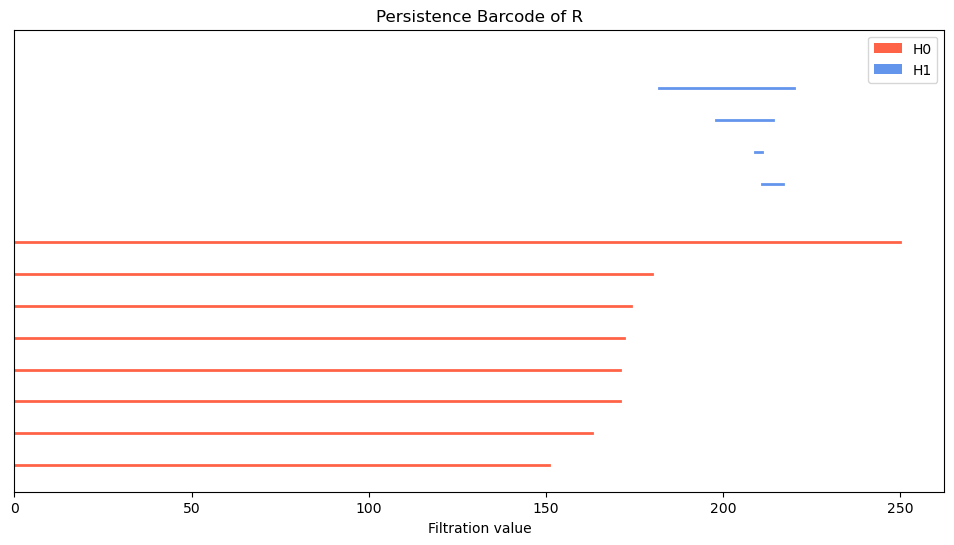

In [4]:
barcode_dim_0 = compute_barcode_from_raster(R,q =3, dim = 0) # 0-dim barcode of R
barcode_dim_1 = compute_barcode_from_raster(R,q =3, dim = 1) # 1-dim barcode of R
print("0-dimensional barcode of R:\n",barcode_dim_0)
print("1-dimensional barcode of R:\n",barcode_dim_1)

fig, ax = plt.subplots(figsize = (12,6))
plot_barcode(barcode_dim_0,barcode_dim_1,r = 250,ax = ax)
ax.set_title('Persistence Barcode of R')
plt.show()

# Figure 5C: Raster $\mathcal{R}'$

Use the code below to reproduce Figure 5C from the paper.  
Note that the final version of the figure was further refined in Adobe Illustrator.

Below we create another raster $\mathcal{R}'$ that shares a similar 0-dimensional barcode with $\mathcal{R}$ but it does not have a 1-dimensional feature.

In [5]:
def finite_deaths_from_H0(dgm0):
    """Return sorted finite death times from a 0-dim diagram."""
    deaths = dgm0[:, 1]
    deaths = deaths[np.isfinite(deaths)]
    return np.sort(deaths)


def H0_loss(current_dgm0, target_deaths):
    """
    Squared L2 distance between sorted finite deaths and target deaths.
    Assumes lengths match (or we truncate to min length).
    """
    cur = finite_deaths_from_H0(current_dgm0)
    tgt = np.sort(np.asarray(target_deaths, float))
    m = min(len(cur), len(tgt))
    return np.sum((cur[:m] - tgt[:m])**2)

def raster_with_target_H0(
    N, T, target_deaths,
    base_rate=0.01,
    n_steps=15000,
    penalty_H1=True,
    lambda_sparse=0.001,
    min_spikes=5,          # << NEW: minimum spikes per neuron
    seed=None
):
    if seed is not None:
        np.random.seed(seed)

    # initial random raster
    raster = (np.random.rand(N, T) < base_rate).astype(int)

    # make sure we start with at least min_spikes per neuron
    for i in range(N):
        idx = np.where(raster[i] == 1)[0]
        if len(idx) < min_spikes:
            # turn on extra spikes at random positions
            extra = np.random.choice(
                np.where(raster[i] == 0)[0],
                size=min_spikes - len(idx),
                replace=False
            )
            raster[i, extra] = 1

    dm = VP_trivial(raster)
    dgm0 = ripser(dm, distance_matrix=True)['dgms'][0]
    dgm1 = ripser(dm, distance_matrix=True)['dgms'][1]

    loss = H0_loss(dgm0, target_deaths)
    if penalty_H1 and len(dgm1) > 0:
        loss += 1000 * np.max(dgm1[:, 1] - dgm1[:, 0])
    loss += lambda_sparse * raster.sum()

    for step in range(n_steps):
        i = np.random.randint(0, N)
        t = np.random.randint(0, T)

        current_val = raster[i, t]

        # if we're about to flip 1->0 and neuron i is already at min_spikes,
        # skip this proposal
        if current_val == 1 and raster[i].sum() <= min_spikes:
            continue

        # propose flip
        raster[i, t] ^= 1

        dm_new = VP_trivial(raster)
        dgm0_new = ripser(dm_new, distance_matrix=True)['dgms'][0]
        dgm1_new = ripser(dm_new, distance_matrix=True)['dgms'][1]

        new_loss = H0_loss(dgm0_new, target_deaths)
        if penalty_H1 and len(dgm1_new) > 0:
            new_loss += 1000 * np.max(dgm1_new[:, 1] - dgm1_new[:, 0])
        new_loss += lambda_sparse * raster.sum()

        if new_loss < loss:
            loss = new_loss
            dgm0, dgm1 = dgm0_new, dgm1_new
        else:
            # reject flip
            raster[i, t] ^= 1

    return raster, dgm0, dgm1, loss



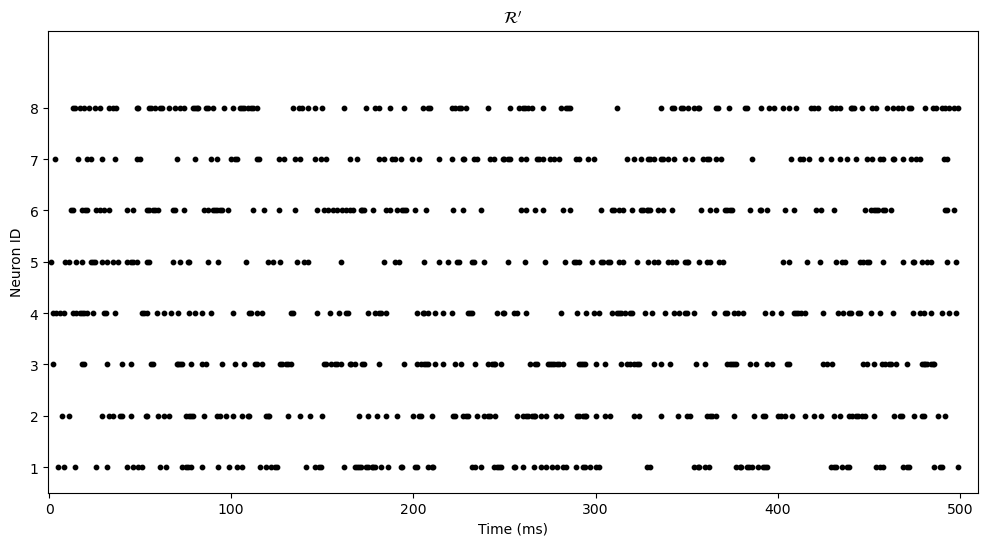

In [6]:
R_prime, dgm0_new, dgm1_new, final_loss = raster_with_target_H0(
    N=8, T=500,
    target_deaths=[150, 162, 170, 170, 171, 173, 179],
    base_rate=0.005,      # very sparse baseline
    n_steps=15000,
    lambda_sparse=0.001,
    min_spikes=5,         # guarantee at least 5 spikes per neuron
    seed=0
)

plot_raster(R_prime,title = '$\mathcal{R}^{\prime}$')
plt.show()



## Figure 5 overall \& Bottleneck distances

Use the code below to reproduce Figure 5 from the paper.  
Note that the final version of the figure was further refined in Adobe Illustrator.  
We also report the bottleneck distances between the degree-0 and degree-1 barcodes of $\mathcal{R}$ and $\mathcal{R}'$.


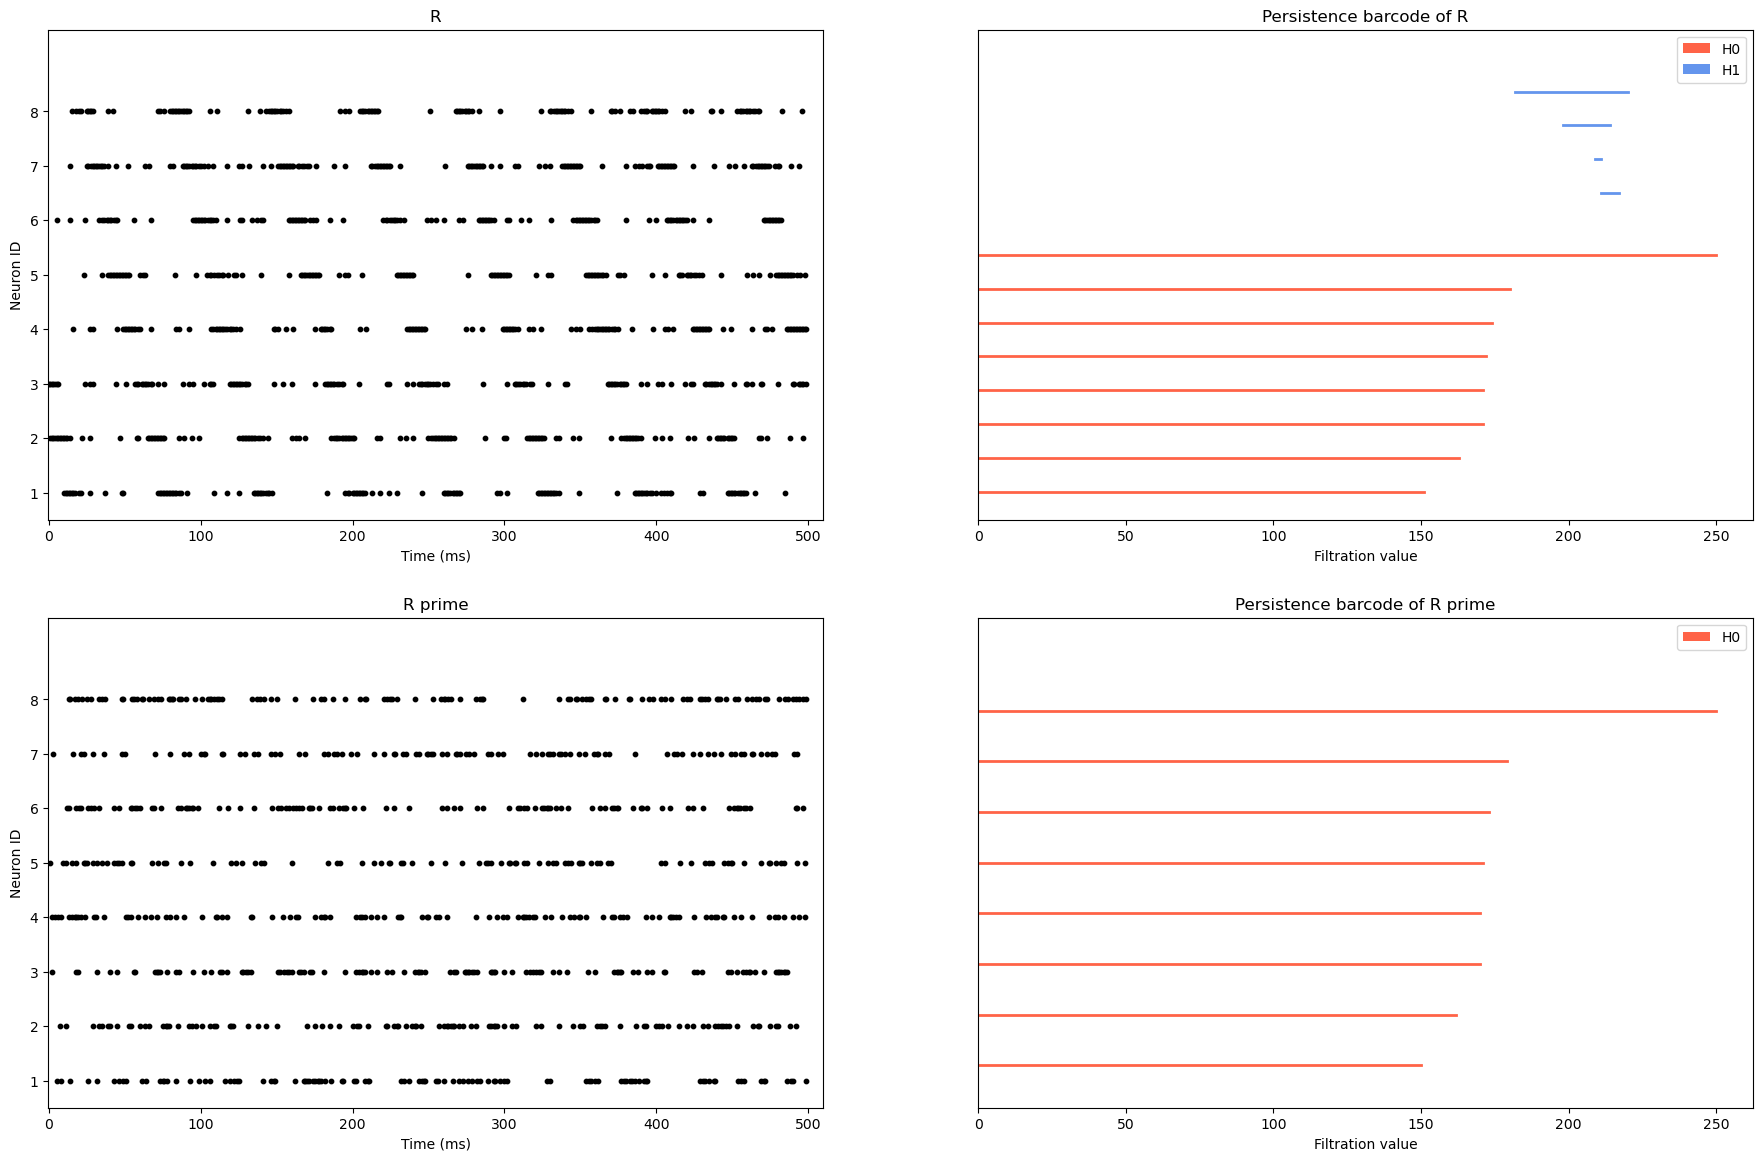

Bottleneck distance between the 0-dimensional barcodes of R and R prime is 1.0
Bottleneck distance between the 1-dimensional barcodes of R and R prime is 19.0


In [7]:
# Compute persistence barcode of R prime
barcode_dim_0_R_prime = compute_barcode_from_raster(R_prime, q = 3, dim = 0)
barcode_dim_1_R_prime = compute_barcode_from_raster(R_prime, q = 3, dim = 1)

fig, axes = plt.subplots(2,2, figsize = (22,14))
# first row first column is R
ax = axes[0,0]
plot_raster(raster=R,title='R',axes= ax)

# first row second column is persistence barcode of R
ax = axes[0,1]
plot_barcode(barcode_dim_0,barcode_dim_1, r = 250,ax = ax)
ax.set_title('Persistence barcode of R')

# second row first column is R prime
ax = axes[1,0]
plot_raster(raster = R_prime,title = 'R prime',axes = ax)

# second row second column is persistence barcode of R prime
ax = axes[1,1]
plot_barcode(barcode_dim_0_R_prime,barcode_dim_1_R_prime, r = 250,ax = ax)
ax.set_title('Persistence barcode of R prime')

plt.show()

# compute bottleneck distances
from persim import bottleneck
bottleneck_distance_between_0_dim = bottleneck_zero(barcode_dim_0,barcode_dim_0_R_prime)
bottleneck_distance_between_1_dim = bottleneck(barcode_dim_1,barcode_dim_1_R_prime)

print('Bottleneck distance between the 0-dimensional barcodes of R and R prime is',bottleneck_distance_between_0_dim)
print('Bottleneck distance between the 1-dimensional barcodes of R and R prime is',bottleneck_distance_between_1_dim)